In [2]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [3]:
from transformers import BertForSequenceClassification, BertTokenizer, Trainer, TrainingArguments

from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
import numpy as np
import evaluate
import torch


In [4]:
from datasets import load_dataset


In [5]:
ds=load_dataset('cornell-movie-review-data/rotten_tomatoes')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

In [6]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

In [7]:
ds_train=ds['train']
ds_test=ds['test']  
df_val=ds['validation']


In [8]:
ds['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 8530
})

In [9]:
df_train=ds_train.to_pandas()
df_test=ds_test.to_pandas()
df_val=df_val.to_pandas()


In [10]:
df_train.head()

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


In [11]:
df_train['label'].value_counts()

,count
label,
1,4265
0,4265


In [12]:
df_train.describe()

,label
count,8530.000000
mean,0.500000
std,0.500029
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


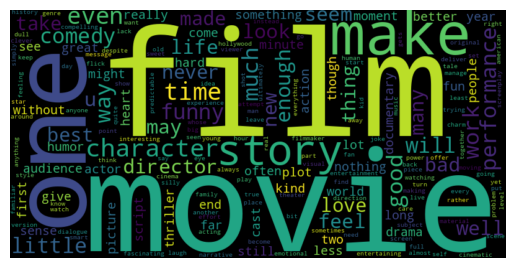

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df_train['text'].tolist())
wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()


In [14]:
import re
import unicodedata

def clean_text(text):
    # Normalize unicode
    text = unicodedata.normalize("NFKD", text)
    
    # Remove HTML tags like <br/>
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)
    
    # Remove non-printable characters
    text = ''.join(ch for ch in text if ch.isprintable())
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [15]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [16]:
def preprocess_and_tokenize(batch):
    batch["text"] = [clean_text(x) for x in batch["text"]]
    return tokenizer(batch["text"], truncation=True)

In [17]:
clean_data = ds.map(preprocess_and_tokenize, batched=True)

Map:   0%|          | 0/8530 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

In [18]:
clean_data

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1066
    })
})

In [19]:
ds_train=clean_data['train']
ds_test=clean_data['test']  
ds_val=clean_data['validation']


In [20]:
df_train=ds_train.to_pandas()
df_test=ds_test.to_pandas()
df_val=ds_val.to_pandas()


In [21]:
df_train.head()

,text,label,input_ids,token_type_ids,attention_mask
0,the rock is destined to be the 21st century's ...,1,"[101, 1996, 2600, 2003, 16036, 2000, 2022, 199...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,"the gorgeously elaborate continuation of "" the...",1,"[101, 1996, 9882, 2135, 9603, 13633, 1997, 100...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,effective but too-tepid biopic,1,"[101, 4621, 2021, 2205, 1011, 8915, 23267, 160...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
3,if you sometimes like to go to the movies to h...,1,"[101, 2065, 2017, 2823, 2066, 2000, 2175, 2000...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,"emerges as something rare , an issue movie tha...",1,"[101, 19391, 2004, 2242, 4678, 1010, 2019, 327...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [22]:
df_train['text'][0]

'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .'

In [23]:
len(df_train['input_ids'][0])

47

In [24]:
padding_trai= DataCollatorWithPadding(tokenizer=tokenizer)

In [25]:
model= AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
training_args = TrainingArguments(
    "bert-rotten-tomatoes",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

In [27]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

In [28]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=clean_data["train"],
    eval_dataset=clean_data["validation"],
    data_collator=padding_trai,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.398246,0.349696,0.854597
2,0.224364,0.464298,0.855535
3,0.132034,0.553955,0.860225


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1602, training_loss=0.24131473679369903, metrics={'train_runtime': 288.8415, 'train_samples_per_second': 88.595, 'train_steps_per_second': 5.546, 'total_flos': 641670308479680.0, 'train_loss': 0.24131473679369903, 'epoch': 3.0})

In [29]:
save_path = "sentiment-bert-model"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('sentiment-bert-model/tokenizer_config.json',
 'sentiment-bert-model/tokenizer.json')

In [30]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
def predict(text):
    model.eval()  # ensures no dropout
    tokens = tokenizer(text, return_tensors="pt", truncation=True).to(device)

    with torch.no_grad():
        output = model(**tokens)
        
    result = torch.argmax(output.logits, dim=-1).item()
    return "Positive" if result == 1 else "Negative"
predict("This movie was fantastic")

'Positive'

In [31]:
predict("This movie is not good")

'Negative'

In [32]:
predict("the role played by the lead actor was amazing but the plot was weak")

'Negative'

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
save_path = "/content/drive/MyDrive/sentiment-bert-model"s

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/sentiment-bert-model/tokenizer_config.json',
 '/content/drive/MyDrive/sentiment-bert-model/tokenizer.json')